Langkah Praktikum Djikstra

Jarak Terpendek dari Node A
A ke A = 0
A ke B = 2
A ke C = 3
A ke D = 5
A ke E = 6

Jalur Terpendek dari A ke E
A -> B -> C -> D -> E


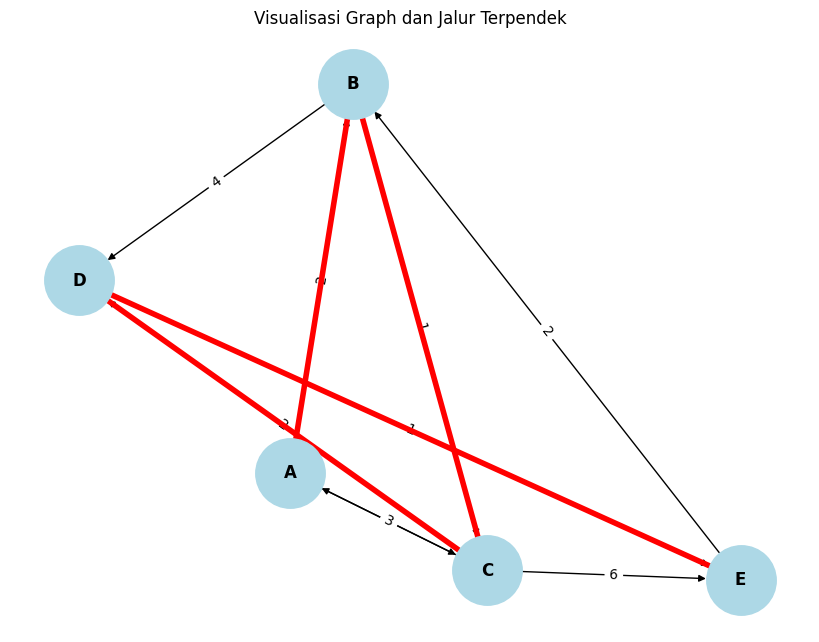

In [13]:
# Install library
!pip install networkx matplotlib

# Import library
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# Membuat graph
graph = {
    'A': {'B': 2, 'C': 5},
    'B': {'C': 1, 'D': 4},
    'C': {'A': 3, 'D': 2, 'E': 6},
    'D': {'E': 1},
    'E': {'B': 2}
}

# Fungsi algoritma Dijkstra
def dijkstra_with_paths(graph, start):
    distances = {node: float('inf') for node in graph}
    distances[start] = 0

    previous = {node: None for node in graph}

    queue = [(0, start)]

    while queue:
        current_distance, current_node = heapq.heappop(queue)

        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight

            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current_node
                heapq.heappush(queue, (distance, neighbor))

    return distances, previous

# Fungsi mencari jalur
def get_path(previous, target):
    path = []

    while target is not None:
        path.insert(0, target)
        target = previous[target]

    return path

# Fungsi visualisasi graph
def visualize_graph(graph, path=None):
    G = nx.DiGraph()

    for node in graph:
        for neighbor, weight in graph[node].items():
            G.add_edge(node, neighbor, weight=weight)

    # Bisa diganti:
    # pos = nx.circular_layout(G)
    pos = nx.spring_layout(G)

    edge_labels = nx.get_edge_attributes(G, 'weight')

    plt.figure(figsize=(8, 6))

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color='lightblue',
        node_size=2500,
        font_weight='bold',
        arrows=True
    )

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels
    )

    # Jalur terpendek warna merah
    if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=path_edges,
            edge_color='red',
            width=4
        )

    plt.title("Visualisasi Graph dan Jalur Terpendek")
    plt.axis('off')
    plt.show()

# Menjalankan program
start_node = 'A'
target_node = 'E'

distances, previous = dijkstra_with_paths(graph, start_node)

path = get_path(previous, target_node)

# Output jarak
print("Jarak Terpendek dari Node A")
for node, distance in distances.items():
    print(f"A ke {node} = {distance}")

# Output jalur
print("\nJalur Terpendek dari A ke E")
print(" -> ".join(path))

# Menampilkan graph
visualize_graph(graph, path)

In [14]:
def get_path(previous, target):
    path = []

    while target is not None:
        path.insert(0, target)
        target = previous[target]

    return path


In [15]:
def visualize_graph(graph, path=None):
    G = nx.DiGraph()

    for node in graph:
        for neighbor, weight in graph[node].items():
            G.add_edge(node, neighbor, weight=weight)

    pos = nx.spring_layout(G)

    edge_labels = nx.get_edge_attributes(G, 'weight')

    plt.figure(figsize=(8, 6))

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color='lightblue',
        node_size=2000,
        font_weight='bold',
        arrows=True
    )

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels
    )

    # Garis tebal untuk jalur terpendek
    if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=path_edges,
            edge_color='red',
            width=3
        )

    plt.title("Visualisasi Graf dan Jalur Terpendek")
    plt.axis('off')
    plt.show()

Latihan / Tugas

Modifikasi graf agar memiliki siklus dan tampilkan visualisasinya

Jarak Terpendek:
{'A': 0, 'B': 2, 'C': 3, 'D': 5, 'E': 6}

Jalur Terpendek A ke E:
A -> B -> C -> D -> E


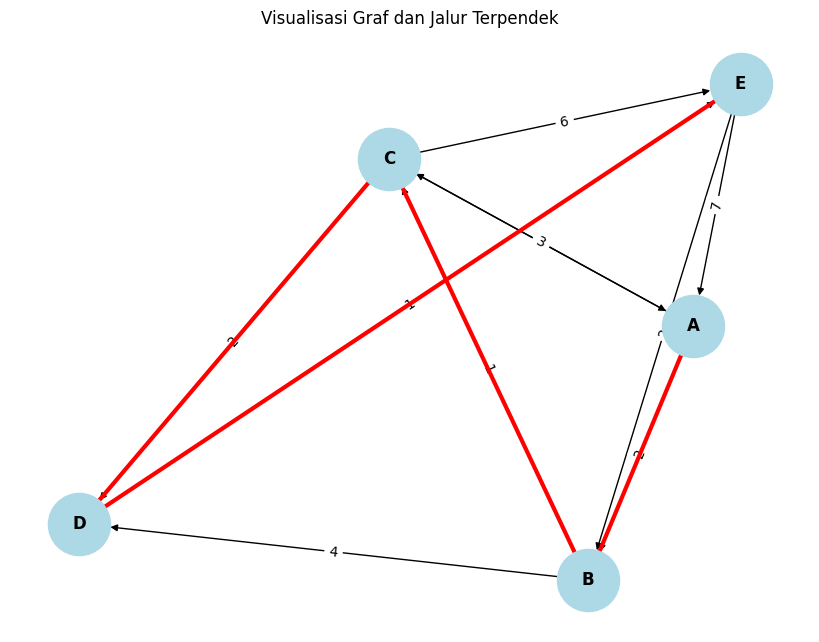

In [20]:
# Graph yang sudah dimodifikasi agar memiliki siklus

graph = {
    'A': {'B': 2, 'C': 5},
    'B': {'C': 1, 'D': 4},
    'C': {'A': 3, 'D': 2, 'E': 6},
    'D': {'E': 1},
    'E': {'A': 7, 'B': 2}
}

# Jalankan algoritma Dijkstra
distances, previous = dijkstra_with_paths(graph, 'A')

# Ambil jalur terpendek ke E
path = get_path(previous, 'E')

print("Jarak Terpendek:")
print(distances)

print("\nJalur Terpendek A ke E:")
print(" -> ".join(path))

# Visualisasi graph
visualize_graph(graph, path)

Tambahkan simpul baru dan lihat perubahan jalur terpendek

Jarak Terpendek:
{'A': 0, 'B': 2, 'C': 3, 'D': 5, 'E': 6, 'F': 7}

Jalur Terpendek A ke F:
A -> B -> C -> D -> F


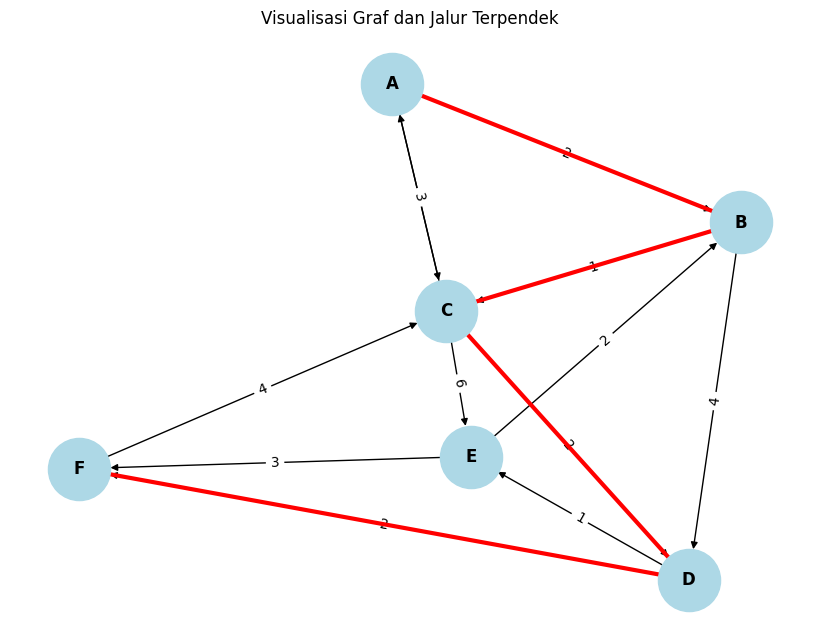

In [21]:
# Graph ditambah simpul baru F

graph = {
    'A': {'B': 2, 'C': 5},
    'B': {'C': 1, 'D': 4},
    'C': {'A': 3, 'D': 2, 'E': 6},
    'D': {'E': 1, 'F': 2},
    'E': {'B': 2, 'F': 3},
    'F': {'C': 4}
}

# Jalankan algoritma Dijkstra
distances, previous = dijkstra_with_paths(graph, 'A')

# Ambil jalur terpendek ke F
path = get_path(previous, 'F')

print("Jarak Terpendek:")
print(distances)

print("\nJalur Terpendek A ke F:")
print(" -> ".join(path))

# Visualisasi graph
visualize_graph(graph, path)

Ganti tata letak graf menggunakan circular_layout

Jarak Terpendek:
{'A': 0, 'B': 2, 'C': 3, 'D': 5, 'E': 6}

Jalur Terpendek A ke E:
A -> B -> C -> D -> E


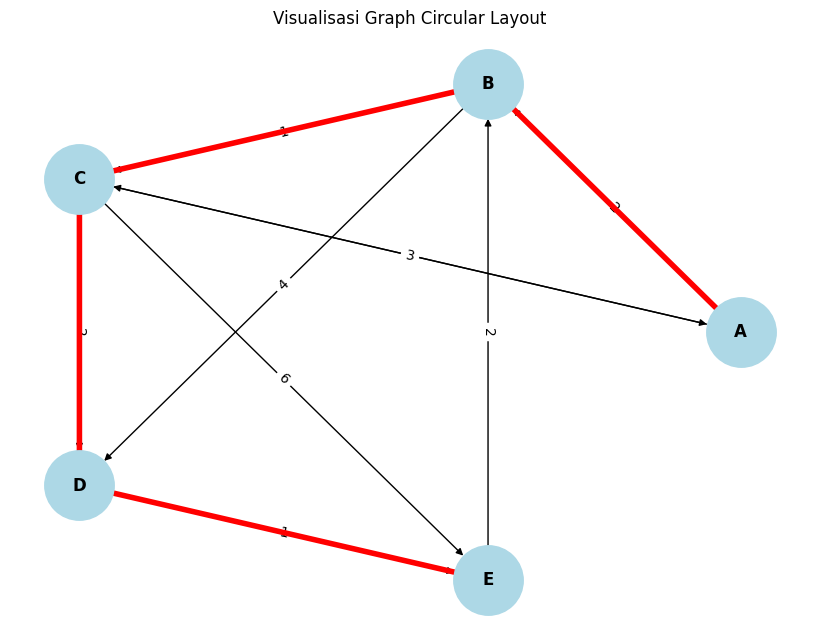

In [22]:
# Graph

graph = {
    'A': {'B': 2, 'C': 5},
    'B': {'C': 1, 'D': 4},
    'C': {'A': 3, 'D': 2, 'E': 6},
    'D': {'E': 1},
    'E': {'B': 2}
}

# Ganti layout menjadi circular
def visualize_graph(graph, path=None):
    G = nx.DiGraph()

    for node in graph:
        for neighbor, weight in graph[node].items():
            G.add_edge(node, neighbor, weight=weight)

    pos = nx.circular_layout(G)

    edge_labels = nx.get_edge_attributes(G, 'weight')

    plt.figure(figsize=(8,6))

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color='lightblue',
        node_size=2500,
        font_weight='bold',
        arrows=True
    )

    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=path_edges,
            edge_color='red',
            width=4
        )

    plt.title("Visualisasi Graph Circular Layout")
    plt.axis('off')
    plt.show()

# Jalankan algoritma
distances, previous = dijkstra_with_paths(graph, 'A')
path = get_path(previous, 'E')

print("Jarak Terpendek:")
print(distances)

print("\nJalur Terpendek A ke E:")
print(" -> ".join(path))

visualize_graph(graph, path)

Contoh

=== JARAK TERPENDEK ===
A ke A = 0
A ke B = 2
A ke C = 3
A ke D = 5
A ke E = 6

=== JALUR TERPENDEK ===
A -> B -> C -> D -> E


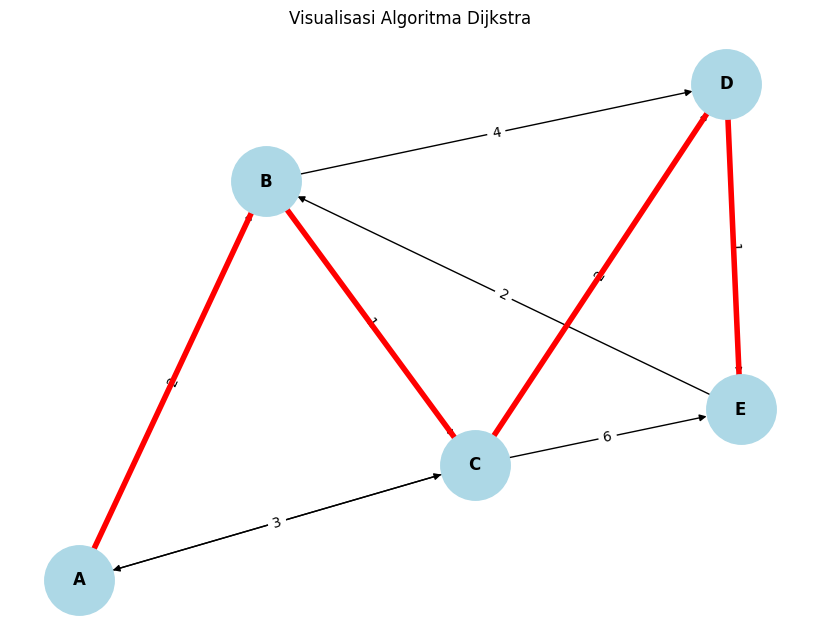

In [18]:
# Install library
!pip install networkx matplotlib

# Import library
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# Membuat graph
graph = {
    'A': {'B': 2, 'C': 5},
    'B': {'C': 1, 'D': 4},
    'C': {'A': 3, 'D': 2, 'E': 6},
    'D': {'E': 1},
    'E': {'B': 2}
}

# Fungsi algoritma Dijkstra
def dijkstra_with_paths(graph, start):
    distances = {node: float('inf') for node in graph}
    distances[start] = 0

    previous = {node: None for node in graph}

    queue = [(0, start)]

    while queue:
        current_distance, current_node = heapq.heappop(queue)

        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight

            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current_node
                heapq.heappush(queue, (distance, neighbor))

    return distances, previous

# Fungsi mencari jalur
def get_path(previous, target):
    path = []

    while target is not None:
        path.insert(0, target)
        target = previous[target]

    return path

# Menjalankan algoritma
start_node = 'A'
target_node = 'E'

distances, previous = dijkstra_with_paths(graph, start_node)
path = get_path(previous, target_node)

# Output jarak
print("=== JARAK TERPENDEK ===")
for node, distance in distances.items():
    print(f"A ke {node} = {distance}")

# Output jalur
print("\n=== JALUR TERPENDEK ===")
print(" -> ".join(path))

# Membuat visualisasi graph
G = nx.DiGraph()

for node in graph:
    for neighbor, weight in graph[node].items():
        G.add_edge(node, neighbor, weight=weight)

# Layout graph
pos = nx.spring_layout(G)

# Ambil label bobot
edge_labels = nx.get_edge_attributes(G, 'weight')

# Membuat gambar
plt.figure(figsize=(8,6))

# Gambar graph
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color='lightblue',
    node_size=2500,
    font_size=12,
    font_weight='bold',
    arrows=True
)

# Menampilkan bobot
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

# Menandai jalur terpendek warna merah
path_edges = list(zip(path, path[1:]))

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=path_edges,
    edge_color='red',
    width=4
)

# Judul
plt.title("Visualisasi Algoritma Dijkstra")

# Menampilkan gambar langsung
plt.show()

Tugas

Jarak Terpendek:
{'A': 0, 'B': 2, 'C': 3, 'D': 5, 'E': 6}

Jalur Terpendek A ke E:
A -> B -> C -> D -> E


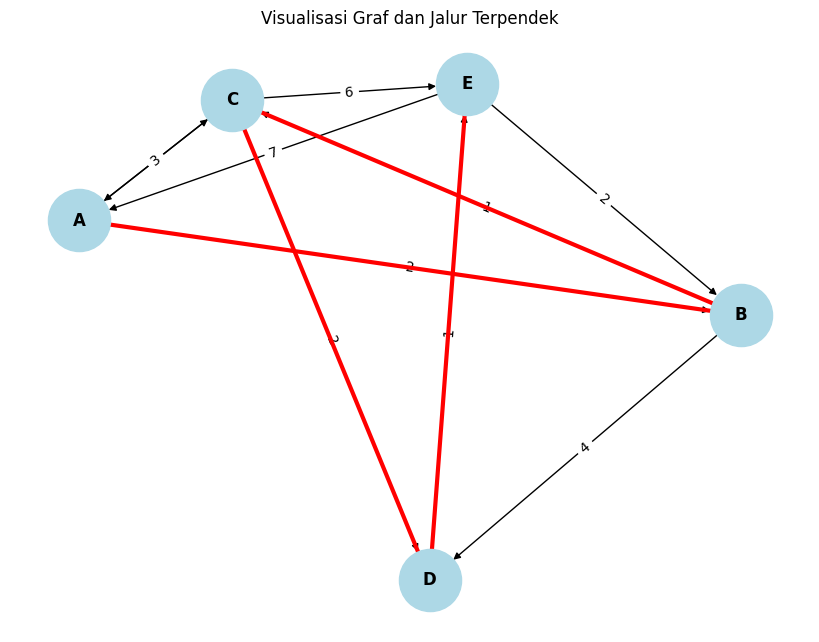

In [19]:
# Graph yang sudah dimodifikasi agar memiliki siklus

graph = {
    'A': {'B': 2, 'C': 5},
    'B': {'C': 1, 'D': 4},
    'C': {'A': 3, 'D': 2, 'E': 6},
    'D': {'E': 1},
    'E': {'A': 7, 'B': 2}
}

# Jalankan algoritma Dijkstra
distances, previous = dijkstra_with_paths(graph, 'A')

# Ambil jalur terpendek ke E
path = get_path(previous, 'E')

print("Jarak Terpendek:")
print(distances)

print("\nJalur Terpendek A ke E:")
print(" -> ".join(path))

# Visualisasi graph
visualize_graph(graph, path)